# Chronos-2 Forecasting Example

From https://github.com/amazon-science/chronos-forecasting?tab=readme-ov-file

## Import Libraries


In [4]:
import pandas as pd  # requires: pip install 'pandas[pyarrow]'
from chronos import Chronos2Pipeline
import matplotlib.pyplot as plt

## Load Data


In [ ]:
pipeline = Chronos2Pipeline.from_pretrained(
    "s3://autogluon/chronos-2", device_map="cuda"
)

# Load historical target values and past values of covariates
context_df = pd.read_parquet(
    "https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/train.parquet"
)

test_df = pd.read_parquet(
    "https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/test.parquet"
)

# (Optional) Load future values of covariates
future_df = test_df.drop(columns="target")

## Generate predictions with covariates


In [3]:
pred_df = pipeline.predict_df(
    context_df,
    future_df=future_df,
    prediction_length=24,  # Number of steps to forecast
    quantile_levels=[0.1, 0.5, 0.9],  # Quantile for probabilistic forecast
    id_column="id",  # Column identifying different time series
    timestamp_column="timestamp",  # Column with datetime information
    target="target",  # Column(s) with time series values to predict
)

## Visualization

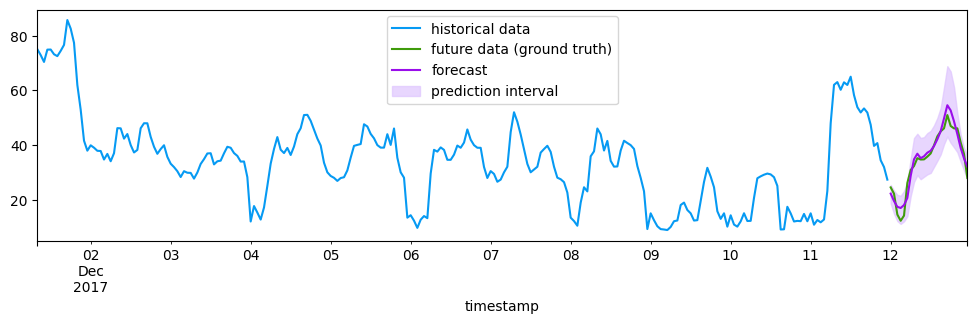

In [6]:
ts_context = context_df.set_index("timestamp")["target"].tail(256)
ts_pred = pred_df.set_index("timestamp")
ts_ground_truth = test_df.set_index("timestamp")["target"]

ts_context.plot(label="historical data", color="xkcd:azure", figsize=(12, 3))
ts_ground_truth.plot(label="future data (ground truth)", color="xkcd:grass green")
ts_pred["predictions"].plot(label="forecast", color="xkcd:violet")
plt.fill_between(
    ts_pred.index,
    ts_pred["0.1"],
    ts_pred["0.9"],
    alpha=0.7,
    label="prediction interval",
    color="xkcd:light lavender",
)
plt.legend()
plt.show()